In [1]:
import json
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder

load_dotenv('../.env')

s3 = boto3.client(
    's3',
    endpoint_url=os.getenv('MINIO_ENDPOINT', 'http://localhost:9000'),
    aws_access_key_id=os.getenv('MINIO_ACCESS_KEY', 'minioadmin'),
    aws_secret_access_key=os.getenv('MINIO_SECRET_KEY', 'minioadmin'),
    region_name='us-east-1',
)

BUCKET = os.getenv('MINIO_BUCKET_PROCESSED', 'healthcare-processed')
print("✓ Setup completo")

✓ Setup completo


In [2]:
BUCKET = os.getenv('MINIO_BUCKET_PROCESSED', 'healthcare-processed')

def load_all_events(bucket: str) -> pd.DataFrame:
    paginator = s3.get_paginator('list_objects_v2')
    records = []
    skipped = 0
    for page in paginator.paginate(Bucket=bucket):
        for obj in page.get('Contents', []):
            try:
                response = s3.get_object(Bucket=bucket, Key=obj['Key'])
                event = json.loads(response['Body'].read())
                if 'risk_level' in event:
                    records.append(event)
                else:
                    skipped += 1
            except Exception:
                skipped += 1
    print(f"Skipped: {skipped} | Cargados: {len(records)}")
    return pd.DataFrame(records)

df = load_all_events(BUCKET)
print(f"✓ Total eventos: {len(df)}")
print(f"✓ Columnas: {df.shape[1]}")
df.head(3)

Skipped: 0 | Cargados: 746
✓ Total eventos: 746
✓ Columnas: 42


,consent_id,schema_version,event_timestamp,patient_id,patient_age,patient_gender,patient_bmi,blood_type,smoker,diabetic,...,anomaly_count,is_high_risk,age_group,bmi_category,comorbidity_count,anesthesia_risk_score,consent_urgency,form_completeness_pct,ml_label,glue_processed_at
0,0019144e-631f-4a9a-b0c5-2930271f71e8,1.0,1776804709474,4f0dc0ca-fcbd-405f-94c7-26b95ce75d17,58,F,32.5,O-,False,False,...,1,False,middle_aged,obese,1,3,scheduled,100.0,0,2026-04-21T20:33:54.438095
1,00233e2b-65bd-4dc8-a5de-a85a0096f29d,1.0,1776804777062,711e8695-5f20-415e-a8fc-8756a0e2c1dd,69,F,35.5,B-,False,False,...,2,False,senior,obese,1,3,scheduled,100.0,0,2026-04-21T20:33:54.451213
2,00eeacd3-0b47-48b7-a37f-b610745e32ff,1.0,1776804834198,d5f58982-77f5-4f71-8cb4-f718bf582fc9,46,M,18.9,O+,False,False,...,2,False,adult,normal,0,2,scheduled,96.4,0,2026-04-21T20:33:54.459777


In [3]:
print("=== Distribución de risk_level ===")
print(df['risk_level'].value_counts())
print()
print("=== Balance del label ML ===")
print(df['ml_label'].value_counts())
print()
print("=== Valores nulos ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

=== Distribución de risk_level ===
risk_level
LOW         276
MEDIUM      274
HIGH        130
CRITICAL     66
Name: count, dtype: int64

=== Balance del label ML ===
ml_label
0    624
1    122
Name: count, dtype: int64

=== Valores nulos ===
Series([], dtype: int64)


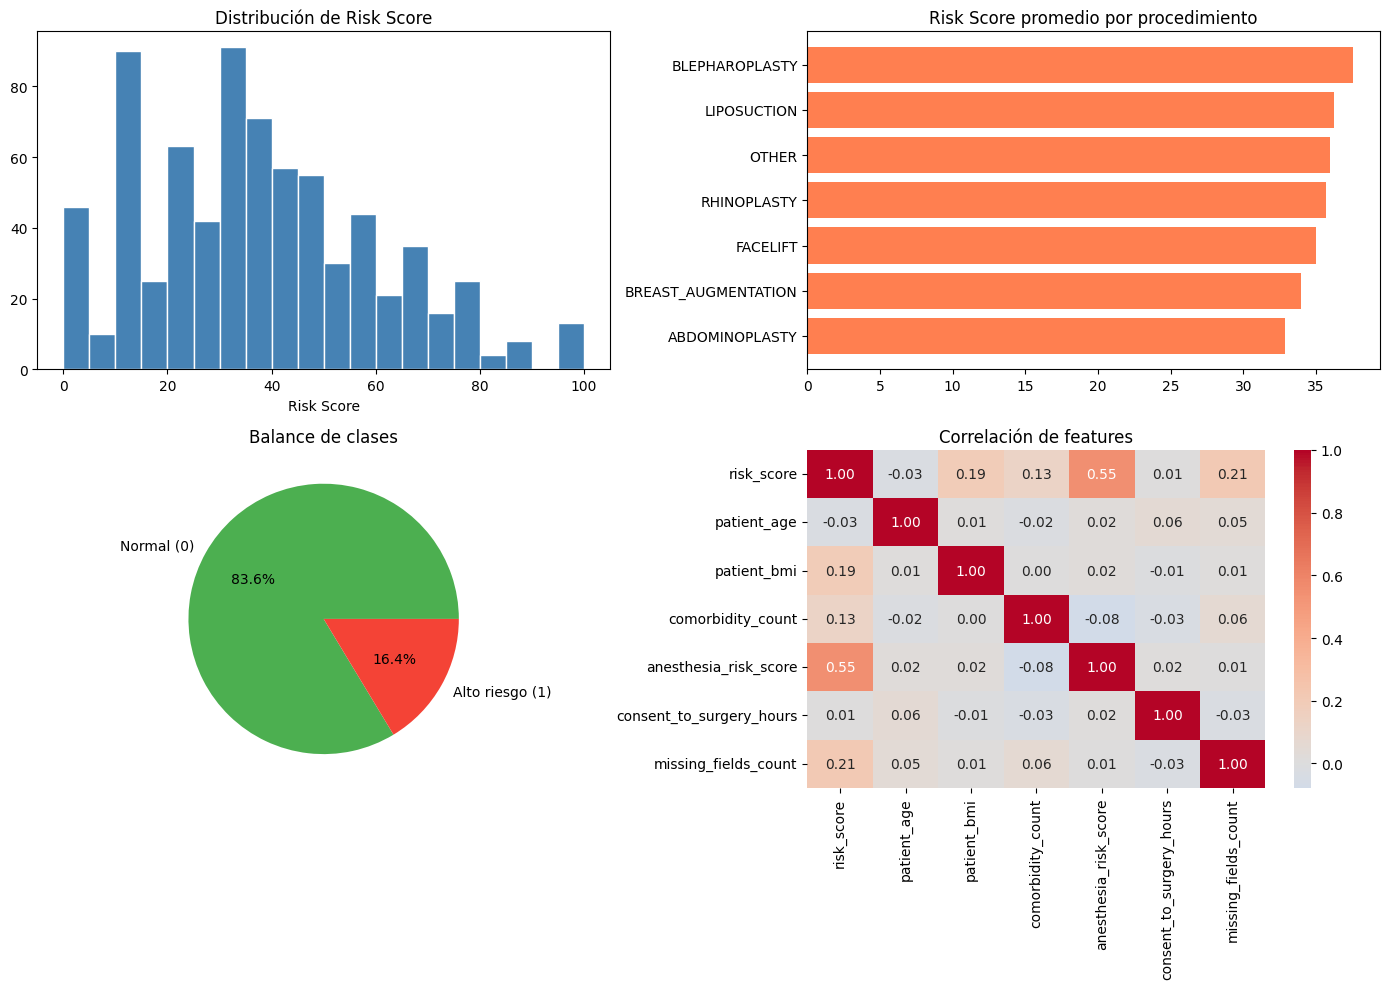

✓ Gráficos guardados en eda_overview.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución de risk_score
axes[0,0].hist(df['risk_score'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Risk Score')
axes[0,0].set_xlabel('Risk Score')

# 2. Risk level por procedimiento
risk_proc = df.groupby('procedure_type')['risk_score'].mean().sort_values()
axes[0,1].barh(risk_proc.index, risk_proc.values, color='coral')
axes[0,1].set_title('Risk Score promedio por procedimiento')

# 3. Balance de clases ML
label_counts = df['ml_label'].value_counts()
axes[1,0].pie(
    label_counts,
    labels=['Normal (0)', 'Alto riesgo (1)'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336']
)
axes[1,0].set_title('Balance de clases')

# 4. Correlación de features numéricas
num_cols = ['risk_score', 'patient_age', 'patient_bmi',
            'comorbidity_count', 'anesthesia_risk_score',
            'consent_to_surgery_hours', 'missing_fields_count']
corr = df[num_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
axes[1,1].set_title('Correlación de features')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ Gráficos guardados en eda_overview.png")

In [5]:
FEATURES = [
    'patient_age', 'patient_bmi', 'comorbidity_count',
    'anesthesia_risk_score', 'consent_to_surgery_hours',
    'missing_fields_count', 'previous_surgeries',
    'risk_acknowledgement', 'estimated_duration_min',
    'is_minor', 'smoker', 'diabetic', 'hypertensive',
    'has_allergies', 'pre_op_labs_completed',
    'consent_signed', 'witness_present',
]

CATEGORICAL = ['procedure_type', 'anesthesia_type',
               'pre_op_clearance', 'consent_urgency',
               'bmi_category', 'age_group']

# Encodear categóricas
le = LabelEncoder()
df_ml = df.copy()
for col in CATEGORICAL:
    if col in df_ml.columns:
        df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))
        FEATURES.append(col + '_enc')

# Convertir booleanos
bool_cols = ['is_minor', 'smoker', 'diabetic', 'hypertensive',
             'has_allergies', 'pre_op_labs_completed',
             'consent_signed', 'witness_present']
for col in bool_cols:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].astype(int)

X = df_ml[FEATURES].fillna(0)
y = df_ml['ml_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Features: {len(FEATURES)}")
print(f"✓ Train: {len(X_train)} | Test: {len(X_test)}")
print(f"✓ Label balance train: {y_train.value_counts().to_dict()}")

✓ Features: 23
✓ Train: 596 | Test: 150
✓ Label balance train: {0: 499, 1: 97}


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("✓ Modelo entrenado")

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\n=== Métricas ===")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Alto riesgo']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

✓ Modelo entrenado

=== Métricas ===
              precision    recall  f1-score   support

      Normal       0.96      0.94      0.95       125
 Alto riesgo       0.71      0.80      0.75        25

    accuracy                           0.91       150
   macro avg       0.84      0.87      0.85       150
weighted avg       0.92      0.91      0.92       150

ROC-AUC: 0.9792


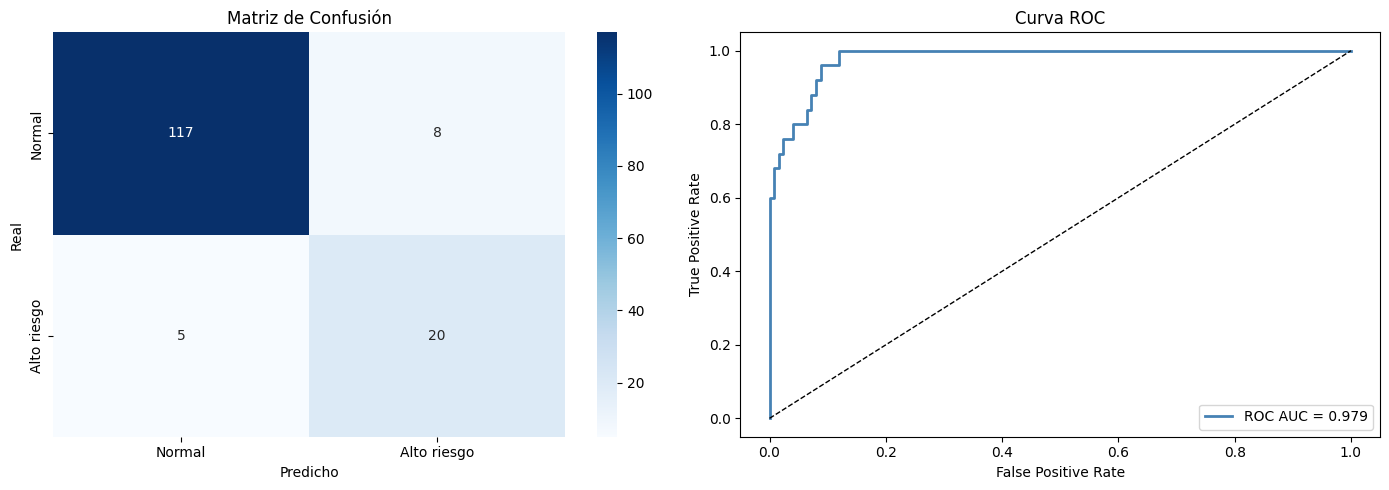

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Alto riesgo'],
            yticklabels=['Normal', 'Alto riesgo'],
            ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue',
             label=f'ROC AUC = {auc_score:.3f}', linewidth=2)
axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_results.png', dpi=120, bbox_inches='tight')
plt.show()

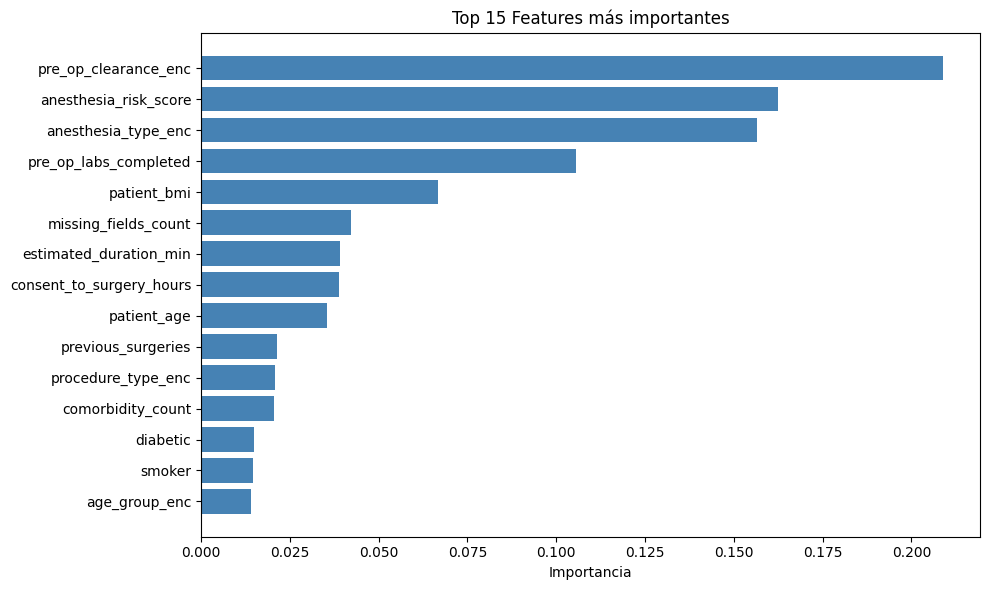


Top 5 features:
              feature  importance
          patient_bmi    0.066707
pre_op_labs_completed    0.105451
  anesthesia_type_enc    0.156480
anesthesia_risk_score    0.162418
 pre_op_clearance_enc    0.208848


In [8]:
importance = pd.DataFrame({
    'feature':   FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('Top 15 Features más importantes')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(importance.tail(5)[['feature','importance']].to_string(index=False))

In [9]:
import pickle
from datetime import datetime

model_path = f"risk_model_{datetime.now().strftime('%Y%m%d')}.pkl"
with open(model_path, 'wb') as f:
    pickle.dump({'model': model, 'features': FEATURES}, f)

print(f"✓ Modelo guardado: {model_path}")
print(f"✓ ROC-AUC final: {roc_auc_score(y_test, y_proba):.4f}")
print("✓ Pipeline completo!")

✓ Modelo guardado: risk_model_20260421.pkl
✓ ROC-AUC final: 0.9792
✓ Pipeline completo!
